Setting up a training loop of Neural KEM with patches

this is an implementation of the following manuscript:

S. Li, K. Gong, R. D. Badawi, E. J. Kim, J. Qi and G. Wang, "Neural KEM: A Kernel Method With Deep Coefficient Prior for PET Image Reconstruction," in IEEE Transactions on Medical Imaging, vol. 42, no. 3, pp. 785-796, March 2023, doi: 10.1109/TMI.2022.3217543

This demo is a jupyter notebook, i.e. intended to be run step by step.

Author: Daniel Deidda

First version: 13th of Nov 2023

CCP SyneRBI Synergistic Image Reconstruction Framework (SIRF).
Copyright 2023 NPL.
SPDX-License-Identifier: Apache-2.0

# Setting up the training


In [1]:
# Get the parent directory
import sys
import os
import pathlib

#parent_dir = os.path.dirname(os.path.realpath('.'))
notebooks_dir = pathlib.Path().parent.absolute() 
parent_dir =  os.path.dirname(notebooks_dir)
print(parent_dir, notebooks_dir)
# Add the parent directory to sys.path
sys.path.append(parent_dir)

/home/nmdicom-recon/devel/github/torchKernel/torchKernel /home/nmdicom-recon/devel/github/torchKernel/torchKernel/notebooks


Directory /home/nmdicom-recon/devel/github/torchKernel/torchKernel/working_dir  already exists!


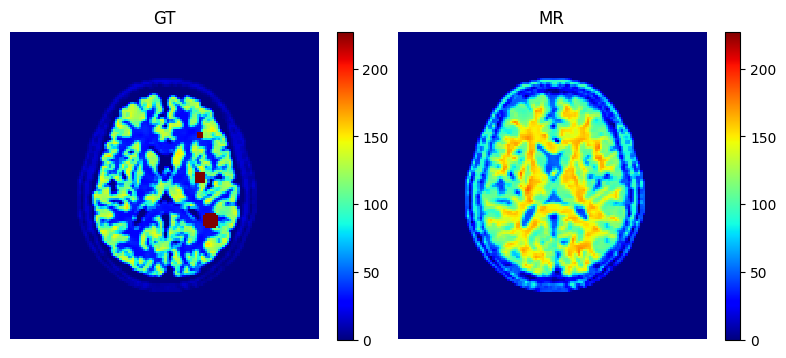

In [5]:
# Import the PET reconstruction engine
import sirf.STIR as pet
# Set the verbosity
pet.set_verbosity(0)
# Store temporary sinograms in RAM
pet.AcquisitionData.set_storage_scheme("memory")
# SIRF STIR message redirector
import sirf

import sirf.STIR as pet
msg = sirf.STIR.MessageRedirector(info=None, warn=None, errr=None)
# Load dataset and model
from torchKernel.kernel.LHK import  BuildK, kernelise_image, set_KOSMAPOSL
from torchKernel.architectures.UNet import  UNet
from torchKernel.utils.torch_operations import  add_noise, tdivide
from torchKernel.utils.plots import plot_many_tensors, plot_many_numpys
from torchKernel.utils.sirf_torch import primal_op as F
from torchKernel.utils.sirf_torch import dual_op as B
from torchKernel.utils.system import create_working_dir_and_move_into
from torchKernel.utils.analytics import estimate_MSE_and_save, plot_losses
from torchKernel.utils.from_sirf_ex import add_np_noise, crop_and_save, get_acquisition_model
#from algorithms.Brain_simulation import make_image_simulation_2d

import os
import numpy as np
import time
import torch

from tqdm.auto import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

working_dir=create_working_dir_and_move_into(parent_dir)
sinogram_template = pet.AcquisitionData('FDG_tumour_sino_2d_noisy_seed0.hs');

y=torch.from_numpy(sinogram_template.as_array()).repeat(1,1,1,1).to(device)

true_brain = pet.ImageData('FDG_tumour_2d.hv') #(144x144)
umap = pet.ImageData('uMap_2d.hv')
T1 = pet.ImageData('T1_2d.hv')
image_template = true_brain#.zoom_image(zooms=(2,2,2))

true_brain_np = true_brain.as_array()
true_brain_tt = torch.from_numpy(true_brain_np).repeat(1,1,1,1).to(device)# tt torch tensor
xt=true_brain_tt

T1_np = T1.as_array()
anat_tt0 = torch.from_numpy(T1_np).repeat(1,1,1,1).to(device)
anat_tt = torch.from_numpy(T1_np/T1_np.max()).repeat(1,1,1,1).to(device)
anat=T1/T1.max()

umap_np = umap.as_array()
umap_tt = torch.from_numpy(umap_np).repeat(1,1,1,1).to(device)

acq_model = get_acquisition_model(sinogram_template, umap)
plot_many_tensors(0 , true_brain_tt.max(), 0,'jet', [true_brain_tt,anat_tt0],['GT','MR'])


In [6]:
#set up model
# create initial image estimate
f = F(image_template,sinogram_template,acq_model).to(device)
b = B(image_template,sinogram_template,acq_model).to(device)

prior=anat_tt
input_im=prior.to(device)
ref = xt.to(device)#torch.reshape(ref,(1,4,4,4))
xr=torch.rand(ref.shape)


In [ ]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed) # if you are using multi-GPU.
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
#set parameters
w=9
k=48
ksigma=1
isVox=False
hybrid=False
LR = 1e-3
#create kernel

# BK=BuildK(self.ksigma,self.is_voxelised,self.save_mem_k,[umap.spacing[0], umap.spacing[1], umap.spacing[2]])

BK=BuildK(ksigma,isVox,0,[umap.spacing[0], umap.spacing[1], umap.spacing[2]])
K=BK(input_im,k,w)

#run nKEM
net = UNet(1,16,1)

data_log = { }
data_log["loss"] = [ ]
data_log['epoch'] = [ ]

num_out_iter=200
num_deep_iter=150 #150
num_em_iter=4
p = pk = []
p += [x for x in net.parameters() ]
optimizer = torch.optim.Adam(p, lr=LR)
Poisson_loss = torch.nn.PoissonNLLLoss(log_input=False,reduction='none')
alpha=torch.ones(xt.shape).to(device)
net_out=torch.ones(xt.shape).to(device)
net_in = prior.type(torch.FloatTensor)

for i in tqdm(range(num_out_iter)):
    with torch.no_grad():
        for it in range(num_em_iter):
            
            ys = y
            sens = b(torch.ones(ys.shape)).to(device) 
            ksens=BK.kernelise_image(K,sens)
            ka= BK.kernelise_image(K,alpha)
            fka=f(ka).to(device)
            grad=b((tdivide(ys,fka)))
            kgrad=BK.kernelise_image(K,grad)
            curr_kem_i =  tdivide(alpha,ksens)*kgrad
            alpha =curr_kem_i
        alpha.requires_grad_(True)

   
    for j in range(num_deep_iter):
            
        def closure():
            
            net_out = curr_kem_i.max()*net(net_in).to(y.device)
            optimizer.zero_grad()
            tot_loss = torch.mean(sens * Poisson_loss(net_out, curr_kem_i))
            net.zero_grad()
            tot_loss.backward()
            data_log["loss"].append(tot_loss.item())
            data_log['epoch'].append(len(data_log["loss"]))  
            return tot_loss
        
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1)
        optimizer.step(closure)        

        net_out = curr_kem_i.max()*net(net_in).to(y.device) 
    alpha=net_out


        #save things
    l=BK.kernelise_image(K,alpha)   
    # print ('outer iter '+str(i))
    string = 'nKEM_k'+str(k)+'_w'+str(w)+'_dit'+str(num_deep_iter)+'_eit'+str(num_em_iter)+'_tit'  
    torch.save({'model_state_dict_net': net.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                }, 'trained_extra.torch_model')
            
    np.save(string+str(i)+'.npy',alpha.detach().cpu().numpy())
    np.save(string+'_data_log',data_log)
        
    

plot_many_tensors(0 , true_brain_tt.max(), 0,'jet', [l,alpha],['image','alpha'])
  

PyTorch GPU memory cleared.
PyTorch GPU memory cleared.


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
#MSE
sub_name1=string
sub_name2='.npy'

estimate_MSE_and_save(sub_name1,num_out_iter, sub_name2, 'neural KEM', xt)

In [ ]:
#loss
loss_name1 = string+'_data_log.npy'
plot_losses(loss_name1)